## 1 - Importing necessary libraries

In [1]:
import sys
import os

# Adicionar o caminho pai ao sys.path
sys.path.insert(0, os.path.abspath('..'))


from commons.utils import barplot_column
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from dotenv import load_dotenv 


%matplotlib inline


In [2]:
custom_palette = sns.dark_palette("#69d", reverse=True, as_cmap=True)

## 2 - Loading Data

In [3]:
load_dotenv()
LOCAL_PATH = os.getenv("LOCAL_PATH")

In [4]:
path_results_public = "survey_results_public.csv"
path_results_schema = "survey_results_schema.csv"
path_minimum_wage = "minimum-wage-by-country-2025.json"

In [5]:
df_res_pub = pd.read_csv(f"{LOCAL_PATH}/stackoverflow-udacity-project-course-2/dataset/{path_results_public}")

In [6]:

df_res_sch = pd.read_csv(f"{LOCAL_PATH}/stackoverflow-udacity-project-course-2/dataset/{path_results_schema}")

In [7]:
df_minimum_wage = pd.read_json(f"{LOCAL_PATH}/stackoverflow-udacity-project-course-2/dataset/{path_minimum_wage}")
df_minimum_wage.columns = ["flagCode", "Country", "MinimumWageHourly", "MinimumWageAnnual"]

## 3 - Data Understanding

The data file for the 2025 Stack Overflow Developer Survey contains numerous columns, each corresponding to a specific survey question or a calculated metric. 
While the exact column names is 170, they generally fall into categories such as: 

**Core Identifiers and Demographics**
- ResponseId: A unique identifier for each respondent.
- Q[Number] (e.g., Q120): Raw question identifiers which are used internally in the dataset, but usually accompanied by a schema file that maps them to the actual question text.
- MainBranch: The primary professional role of the respondent (e.g., "Developer by profession").
- Age: The age group of the developer (e.g., 18-24, 25-34).
- Employment: Employment status (e.g., full-time, part-time, student).
- Country: The country where the respondent resides.
- EdLevel: The highest level of formal education attained.
- RemoteWork: Working situation (e.g., fully remote, hybrid, in-person). 

**Technology Usage and Preference**
- LanguageHaveWorkedWith/WantToWorkWith: The programming, scripting, and markup languages the developer has worked with in the past year or wants to learn, with responses often separated by semicolons.
- DatabaseHaveWorkedWith/WantToWorkWith: Similarly, the databases the developer uses or plans to use (e.g., PostgreSQL, MySQL, MongoDB).
- PlatformHaveWorkedWith/WantToWorkWith: Development platforms (e.g., Android, AWS, Docker).
- WebframeHaveWorkedWith/WantToWorkWith: Web frameworks (e.g., React, Vue.js, Django).
- ToolsTechHaveWorkedWith/WantToWorkWith: Other development tools and technologies.
- OpSys: The primary operating system used. 

**AI Tools and Usage**
- AI columns*: A new focus for the 2025 survey, these columns capture usage, sentiment, and trust regarding AI tools and agents.
- AIAgent: Whether the developer uses AI agents at work and how frequently (daily, weekly, etc.).
- AIToolsSentiment: The developer's general feeling about AI tools (favorable, indifferent, unfavorable).
- AIIncreasedProductivity: The perceived impact of AI tools on personal or team productivity. 

**Professional and Personal Details**- 
- YearsCode: The total number of years the respondent has been coding.
- DevType: The specific developer roles held (e.g., full-stack, back-end, mobile, architect).
- Salary: Information related to compensation, often with conversions to USD for easier analysis.
- JobSat: Job satisfaction level (e.g., Very satisfied, Slightly dissatisfied).
- LearnCode: Methods used to learn coding (e.g., online courses, books, self-taught).

#### More in-depth explanation for each question

- ResponseId: unique id
- MainBranch: primary professional role
- Age: age group
- EdLevel: highest level of formal education
- Employment: employment status
- EmploymentAddl: additional activities engaged
- WorkExp: years of working experience
- LearnCodeChoose: begin to learn to code/new skill/programming language last year
- LearnCode: how did the respondant learnt
- LearnCodeAI: spent time learning AI-programming or AI-enabled tooling
- AILearnHow: how did the respondant learnt to code for AI
- YearsCode: how many years coding
- DevType: specific developer roles
- OrgSize: organization size in number of employees
- ICorPM: individual contributor or people manager
- RemoteWork: Working situation (e.g., fully remote, hybrid, in-person)
- PurchaseInfluence: did the respondant influenced or endorsed a new technology at the organization
- TechEndorseIntro: influence or endorse in work environment (work/school/personal project)
- TechEndorse_1: check_schema
- TechEndorse_2: check_schema
- TechEndorse_3: check_schema
- TechEndorse_4: check_schema
- TechEndorse_5: 
- TechEndorse_6:
- TechEndorse_7: 
- TechEndorse_8: 
- TechEndorse_9: 
- TechEndorse_13: Other (please specify):
- TechEndorse_13_TEXT: Free text
- TechOppose_1: 
- TechOppose_2:
- TechOppose_3: 
- TechOppose_5: 
- TechOppose_7:
- TechOppose_9:
- TechOppose_11:
- TechOppose_13: 
- TechOppose_16: 
- TechOppose_15: Other (please specify):
- TechOppose_15_TEXT: Free text
- Industry: What industry works for
- JobSatPoints_1: 
- JobSatPoints_4: 
- JobSatPoints_5: 
- JobSatPoints_6: 
- JobSatPoints_7:
- JobSatPoints_8:
- JobSatPoints_9:
- JobSatPoints_10: 
- JobSatPoints_11: 
- JobSatPoints_13:
- JobSatPoints_14: 
- JobSatPoints_15:
- JobSatPoints_16: 
- JobSatPoints_15_TEXT: 
- AIThreat: Believe AI is a threat for the job
- NewRole: Considered career change/transitioned to a new role
- ToolCountWork: How many distinct software applications or platforms used at work
- ToolCountPersonal: How many distinct software applications or platforms used for personal projects
- Country: Where are you from
- Currency: Currency used daily
- CompTotal: Annual compensation
- LanguageChoice: Works with programming? (yes/no/idk)
- LanguageHaveWorkedWith: list of programs
- LanguageWantToWorkWith: list of programs
- LanguageAdmired: list of languages
- LanguagesHaveEntry: free text
- LanguagesWantEntry: free text
- DatabaseChoice: Works with dbs? (yes/no/idk)
- DatabaseHaveWorkedWith: list of dbs
- DatabaseWantToWorkWith: list of dbs
- DatabaseAdmired: list of dbs
- DatabaseHaveEntry: free text
- DatabaseWantEntry: free text
- PlatformChoice: Works with cloud platforms? (yes/no/idk)
- PlatformHaveWorkedWith: list of platforms
- PlatformWantToWorkWith: list of platforms
- PlatformAdmired: list of platforms
- PlatformHaveEntry: free text
- PlatformWantEntry: free text
- WebframeChoice: Works with cloud web frameworks? (yes/no/idk)
- WebframeHaveWorkedWith: list of frameworks
- WebframeWantToWorkWith: list of frameworks
- WebframeAdmired: list of frameworks
- WebframeHaveEntry: free text
- WebframeWantEntry: free text
- DevEnvsChoice:
- DevEnvsHaveWorkedWith:
- DevEnvsWantToWorkWith:
- DevEnvsAdmired:
- DevEnvHaveEntry:
- DevEnvWantEntry:
- SOTagsHaveWorkedWith:
- SOTagsWantToWorkWith:
- SOTagsAdmired:
- SOTagsHaveEntry:
- SOTagsWant Entry:
- OpSysPersonal use:
- OpSysProfessional use:
- OfficeStackAsyncHaveWorkedWith:
- OfficeStackAsyncWantToWorkWith:
- OfficeStackAsyncAdmired:
- OfficeStackHaveEntry:
- OfficeStackWantEntry:
- CommPlatformHaveWorkedWith:
- CommPlatformWantToWorkWith:
- CommPlatformAdmired:
- CommPlatformHaveEntr:
- CommPlatformWantEntr:
- AIModelsChoice:
- AIModelsHaveWorkedWith:
- AIModelsWantToWorkWith:
- AIModelsAdmired:
- AIModelsHaveEntry:
- AIModelsWantEntry:
- SOAccount:
- SOVisitFreq:
- SODuration:
- SOPartFreq:
- SO_Dev_Content:
- SO_Actions_1:
- SO_Actions_16:
- SO_Actions_3:
- SO_Actions_4:
- SO_Actions_5:
- SO_Actions_6:
- SO_Actions_9:
- SO_Actions_7:
- SO_Actions_10:
- SO_Actions_15:
- SO_Actions_15_TEXT:
- SOComm:
- SOFriction:
- AISelect:
- AISent:
- AIAcc:
- AIComplex:
- AIToolCurrently partially AI:
- AIToolDon't plan to use AI for this task:
- AIToolPlan to partially use AI:
- AIToolPlan to mostly use AI:
- AIToolCurrently mostly AI:
- AIFrustration:
- AIExplain:
- AIAgents:
- AIAgentChange:
- AIAgent_Uses:
- AgentUsesGeneral:
- AIAgentImpactSomewhat agree:
- AIAgentImpactNeutral:
- AIAgentImpactSomewhat disagree:
- AIAgentImpactStrongly agree:
- AIAgentImpactStrongly disagree:
- AIAgentChallengesNeutral:
- AIAgentChallengesSomewhat disagree:
- AIAgentChallengesStrongly agree:
- AIAgentChallengesSomewhat agree:
- AIAgentChallengesStrongly disagree:
- AIAgentKnowledge:
- AIAgentKnowWrite:
- AIAgentOrchestration:
- AIAgentOrchWrite:
- AIAgentObserveSecure:
- AIAgentObsWrite:
- AIAgentExternal:
- AIAgentExtWrite:
- AIHuman:
- AIOpen:
- ConvertedCompYearly:
- JobSat: How satisfied are you in your current professional developer role (1-10)

In [8]:
df_res_sch[df_res_sch['qname']=='LanguageAdmired']

,qid,qname,question,type,sub,sq_id


In [9]:
df_res_pub['LanguageAdmired']

0                                            Dart
1                                            Java
2             Dart;HTML/CSS;JavaScript;TypeScript
3                                     Java;Kotlin
4        C#;Java;JavaScript;Python;SQL;TypeScript
                           ...                   
49118                                         NaN
49119                                         NaN
49120                                         NaN
49121                                      C#;SQL
49122                                         NaN
Name: LanguageAdmired, Length: 49123, dtype: object

In [10]:
df_res_pub['LanguageHaveWorkedWith']

0                         Bash/Shell (all shells);Dart;SQL
1                                                     Java
2                      Dart;HTML/CSS;JavaScript;TypeScript
3                                          Java;Kotlin;SQL
4        C;C#;C++;Delphi;HTML/CSS;Java;JavaScript;Lua;P...
                               ...                        
49118                                                  NaN
49119                                                  NaN
49120                                                  NaN
49121                                               C#;SQL
49122                                                  NaN
Name: LanguageHaveWorkedWith, Length: 49123, dtype: object

In [11]:
df_res_pub['LanguageWantToWorkWith']

0                                                     Dart
1                                        Java;Python;Swift
2                      Dart;HTML/CSS;JavaScript;TypeScript
3                                              Java;Kotlin
4                 C#;Java;JavaScript;Python;SQL;TypeScript
                               ...                        
49118                                                  NaN
49119                                                  NaN
49120                                                  NaN
49121    C#;HTML/CSS;Java;JavaScript;Kotlin;PHP;Python;...
49122                                                  NaN
Name: LanguageWantToWorkWith, Length: 49123, dtype: object

In [12]:
df_res_pub.shape

(49123, 170)

#### Main Branch Analysis

In [13]:
df_main_branch = df_res_pub.MainBranch.value_counts().reset_index()

In [14]:
df_main_branch

,MainBranch,count
0,I am a developer by profession,37418
1,"I am not primarily a developer, but I write co...",4888
2,I am learning to code,2580
3,I code primarily as a hobby,1920
4,"I used to be a developer by profession, but no...",1322
5,I work with developers or my work supports dev...,995


c:\Users\vinni\Documents\Projects\GitProjects\learning-projects\stackoverflow-udacity-project-course-2\commons\utils.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Category")


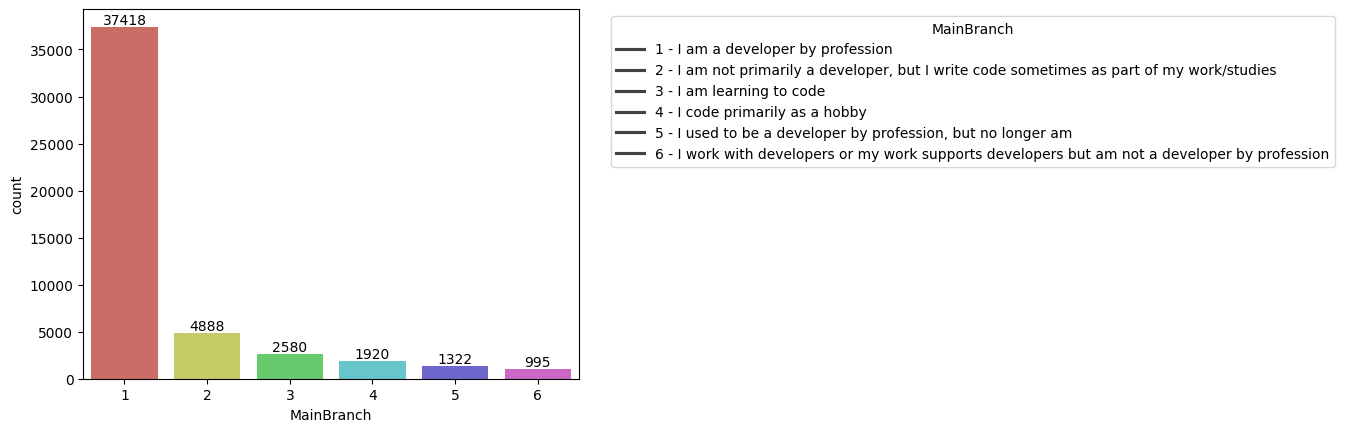

In [15]:
barplot_column(df_main_branch, "MainBranch")

#### Employment analysis

In [16]:
df_res_pub.Employment.value_counts()

Employment
Employed                                                33709
Independent contractor, freelancer, or self-employed     6700
Student                                                  4420
Not employed                                             2222
Retired                                                   708
I prefer not to say                                       518
Name: count, dtype: int64

In [17]:
df_employ = df_res_pub.Employment.value_counts().reset_index()


c:\Users\vinni\Documents\Projects\GitProjects\learning-projects\stackoverflow-udacity-project-course-2\commons\utils.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Category")


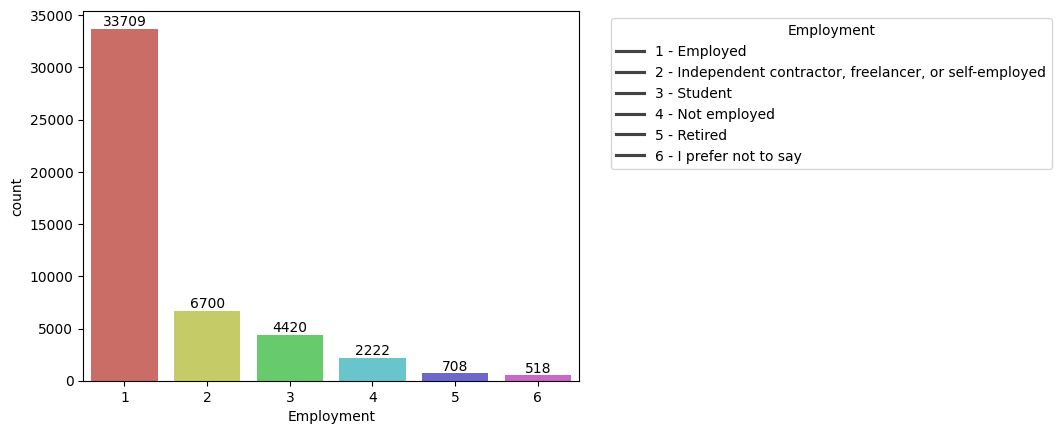

In [18]:
barplot_column(df_employ, "Employment")

In [19]:
df_res_pub.EmploymentAddl.value_counts()

EmploymentAddl
None of the above                                                                                                                                             18593
Caring for dependents (children, elderly, etc.)                                                                                                                5311
Engaged in paid work (20-29 hours per week)                                                                                                                    4720
Attending school (full-time)                                                                                                                                   2757
Volunteering (regularly)                                                                                                                                       2512
                                                                                                                                                              ...  
N

In [20]:
for column in df_res_pub.columns:
    print(f"{column} ,")

ResponseId ,
MainBranch ,
Age ,
EdLevel ,
Employment ,
EmploymentAddl ,
WorkExp ,
LearnCodeChoose ,
LearnCode ,
LearnCodeAI ,
AILearnHow ,
YearsCode ,
DevType ,
OrgSize ,
ICorPM ,
RemoteWork ,
PurchaseInfluence ,
TechEndorseIntro ,
TechEndorse_1 ,
TechEndorse_2 ,
TechEndorse_3 ,
TechEndorse_4 ,
TechEndorse_5 ,
TechEndorse_6 ,
TechEndorse_7 ,
TechEndorse_8 ,
TechEndorse_9 ,
TechEndorse_13 ,
TechEndorse_13_TEXT ,
TechOppose_1 ,
TechOppose_2 ,
TechOppose_3 ,
TechOppose_5 ,
TechOppose_7 ,
TechOppose_9 ,
TechOppose_11 ,
TechOppose_13 ,
TechOppose_16 ,
TechOppose_15 ,
TechOppose_15_TEXT ,
Industry ,
JobSatPoints_1 ,
JobSatPoints_4 ,
JobSatPoints_5 ,
JobSatPoints_6 ,
JobSatPoints_7 ,
JobSatPoints_8 ,
JobSatPoints_9 ,
JobSatPoints_10 ,
JobSatPoints_11 ,
JobSatPoints_13 ,
JobSatPoints_14 ,
JobSatPoints_15 ,
JobSatPoints_16 ,
JobSatPoints_15_TEXT ,
AIThreat ,
NewRole ,
ToolCountWork ,
ToolCountPersonal ,
Country ,
Currency ,
CompTotal ,
LanguageChoice ,
LanguageHaveWorkedWith ,
LanguageWantToWor

In [21]:
for i in df_res_sch.loc[:, 'question']:
    print(i)

What attracts you to a technology or causes you to endorse it (most to least important)?
What attracts you to a technology or causes you to endorse it (most to least important)?
What attracts you to a technology or causes you to endorse it (most to least important)?
What attracts you to a technology or causes you to endorse it (most to least important)?
What attracts you to a technology or causes you to endorse it (most to least important)?
What attracts you to a technology or causes you to endorse it (most to least important)?
What attracts you to a technology or causes you to endorse it (most to least important)?
What attracts you to a technology or causes you to endorse it (most to least important)?
What attracts you to a technology or causes you to endorse it (most to least important)?
What attracts you to a technology or causes you to endorse it (most to least important)?
What attracts you to a technology or causes you to endorse it (most to least important)?
What would turn you o

### 4 - Preprocess

In the column "MainBranch", we filter out the respondents in categories "I am learning to code", "I code primarily as a hobby" and "I used to be a developer by profession, but no longer am" because we are trying to predict salary. As the people belonging to these categories don't have their jobs direct connected with the survey, we treat them as outliers. 

In [22]:
# Validate the filter
print(f"Before: \n{df_res_pub.MainBranch.value_counts()}")

# Filter out categories not directly related to professional developers
df_res_pub2 = df_res_pub[~df_res_pub["MainBranch"].isin([
    "I am learning to code",
    "I code primarily as a hobby",
    "I used to be a developer by profession, but no longer am"
])]

# Validate the filter
print(f"\nAfter: \n{df_res_pub2.MainBranch.value_counts()}")

Before: 
MainBranch
I am a developer by profession                                                                37418
I am not primarily a developer, but I write code sometimes as part of my work/studies          4888
I am learning to code                                                                          2580
I code primarily as a hobby                                                                    1920
I used to be a developer by profession, but no longer am                                       1322
I work with developers or my work supports developers but am not a developer by profession      995
Name: count, dtype: int64

After: 
MainBranch
I am a developer by profession                                                                37418
I am not primarily a developer, but I write code sometimes as part of my work/studies          4888
I work with developers or my work supports developers but am not a developer by profession      995
Name: count, dtype: int64


For the "Employment" column, we filter out the respondents in categories "Student", "Not employed", "Retired" and "I prefer not to say" for the same reaseon as in "MainBranch"

In [23]:

print(f"Before: \n{df_res_pub2.Employment.value_counts()}")

# Filter out categories without direct professional connection
df_res_pub3 = df_res_pub2[~df_res_pub2["Employment"].isin([
    "Student",
    "Not employed",
    "Retired",
    "I prefer not to say"
])]

# Validate the filter
print(f"\nAfter: \n{df_res_pub3.Employment.value_counts()}")

Before: 
Employment
Employed                                                32249
Independent contractor, freelancer, or self-employed     6117
Student                                                  2346
Not employed                                             1413
I prefer not to say                                       294
Retired                                                   223
Name: count, dtype: int64

After: 
Employment
Employed                                                32249
Independent contractor, freelancer, or self-employed     6117
Name: count, dtype: int64


Finally, for the "LanguageChoice" columns, we filter out the respondents that answered "yes". These are the people that worked with programming languages in the past year.

In [24]:
print(f"Before: \n{df_res_pub3.LanguageChoice.value_counts()}")

# Filter out categories without direct professional connection
df_res_pub4 = df_res_pub3[~(df_res_pub3["LanguageChoice"] == "Yes")]

# Validate the filter
print(f"\nAfter: \n{df_res_pub4.LanguageChoice.value_counts()}")

Before: 
LanguageChoice
Yes    25870
No       395
Name: count, dtype: int64

After: 
LanguageChoice
No    395
Name: count, dtype: int64


#### 4.1 - Selecting Revelant Columns

In [25]:
columns = [
    "ResponseId",
    "MainBranch",
    "Age",
    "EdLevel",
    "WorkExp",
    "LearnCodeChoose",  # did learn code last year
    "LearnCodeAI",      # did learn AI last year
    "YearsCode",
    "DevType",
    "OrgSize",
    "ICorPM",           # Individual contibutor or project manager
    "RemoteWork",
    "Industry",
    "NewRole",          # Filter only the transitioned as True -> rest is False (I have transitioned into a new career and/or industry voluntarily | I have transitioned into a new career and/or industry involuntarily)
    "ToolCountWork",
    "Country",
    "Currency",
    "LanguageHaveWorkedWith",
    "LanguageWantToWorkWith",
    "DatabaseChoice",
    "DatabaseHaveWorkedWith",
    "DatabaseWantToWorkWith",
    "PlatformChoice",
    "PlatformHaveWorkedWith",
    "PlatformWantToWorkWith",
    "WebframeChoice",
    "WebframeHaveWorkedWith",
    "WebframeWantToWorkWith",
    "DevEnvsChoice",
    "DevEnvsHaveWorkedWith",
    "DevEnvsWantToWorkWith",
    "OpSysProfessional use",
    "OfficeStackAsyncHaveWorkedWith",
    "OfficeStackAsyncWantToWorkWith",
    "CommPlatformHaveWorkedWith",
    "CommPlatformWantToWorkWith",
    "AIModelsChoice",
    "AIModelsHaveWorkedWith",
    "AIModelsWantToWorkWith",
    "AISelect",
    "AIToolCurrently partially AI",
    "AIToolDon't plan to use AI for this task",
    "AIToolPlan to partially use AI",
    "AIToolPlan to mostly use AI",
    "AIToolCurrently mostly AI",
    "AIAgentImpactSomewhat agree",
    "AIAgentImpactNeutral",
    "AIAgentImpactSomewhat disagree",
    "AIAgentImpactStrongly agree",
    "AIAgentImpactStrongly disagree",
    "AIAgentChallengesNeutral",
    "AIAgentChallengesSomewhat disagree",
    "AIAgentChallengesStrongly agree",
    "AIAgentChallengesSomewhat agree",
    "AIAgentChallengesStrongly disagree",
    "AIAgentKnowledge",
    "AIAgentOrchestration",
    "AIAgentObserveSecure",
    "AIAgentExternal",
    "CompTotal",
    "ConvertedCompYearly"
]

In [26]:
# Select relevant columns for analysis
df_res_pub_final = df_res_pub4[columns]

#### 4.2 - Treating Values

In [27]:
df_res_pub_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13155 entries, 8 to 49122
Data columns (total 61 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   ResponseId                                13155 non-null  int64  
 1   MainBranch                                13155 non-null  object 
 2   Age                                       13155 non-null  object 
 3   EdLevel                                   12451 non-null  object 
 4   WorkExp                                   11283 non-null  float64
 5   LearnCodeChoose                           11538 non-null  object 
 6   LearnCodeAI                               10370 non-null  object 
 7   YearsCode                                 9081 non-null   float64
 8   DevType                                   9201 non-null   object 
 9   OrgSize                                   7983 non-null   object 
 10  ICorPM                                 

In [28]:
df_res_pub_final.shape

(13155, 61)

##### 4.1.1 - Education Level
Here we fill the columns with the label "Other (please specify)" as we assume the respondant choose not to inform.

In [29]:
df_res_pub_final.EdLevel.value_counts()

EdLevel
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                                          5722
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                                       3387
Some college/university study without earning a degree                                1333
Professional degree (JD, MD, Ph.D, Ed.D, etc.)                                         657
Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)     629
Associate degree (A.A., A.S., etc.)                                                    407
Other (please specify):                                                                161
Primary/elementary school                                                              155
Name: count, dtype: int64

In [30]:
df_res_pub_final['EdLevel'] = df_res_pub_final['EdLevel'].fillna("Other (please specify):")
assert df_res_pub_final['EdLevel'].isnull().sum() == 0

C:\Users\vinni\AppData\Local\Temp\ipykernel_3936\2228486902.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_res_pub_final['EdLevel'] = df_res_pub_final['EdLevel'].fillna("Other (please specify):")


##### 4.1.2 - Country analysis

Analysing missing data

In [31]:
df_res_pub_final.Country.isnull().sum()

np.int64(10481)

Analysing country distribuition

In [32]:
df_country = df_res_pub_final.Country.value_counts().reset_index()

In [33]:
df_prevalent_countries = df_country[df_country['count'] >= 10]

In [34]:
from commons.utils import barplot_column

c:\Users\vinni\Documents\Projects\GitProjects\learning-projects\stackoverflow-udacity-project-course-2\commons\utils.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Category")


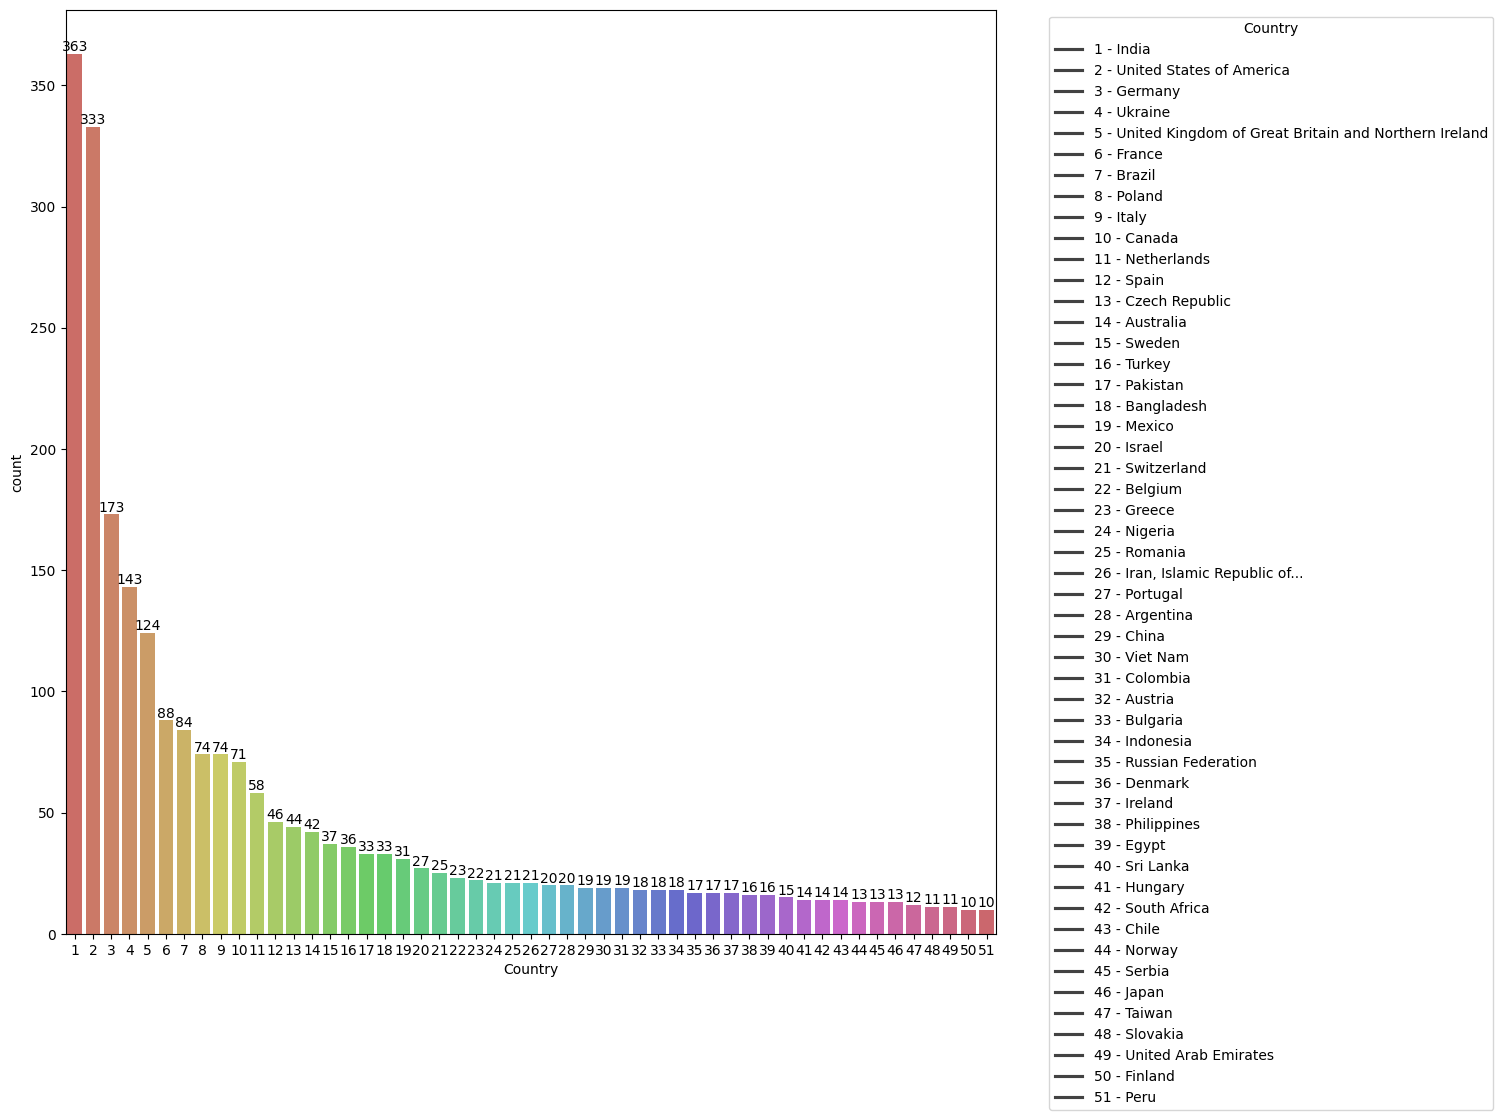

In [40]:
plt.figure(figsize=(12, 12))
barplot_column(df_prevalent_countries, "Country")

In [36]:
df_country = pd.merge(df_country, df_minimum_wage, on="Country", how="left")

In [120]:
df_country[df_country['MinimumWageAnnual'] == df_country['MinimumWageAnnual'].min()]

,Country,count,flagCode,MinimumWageHourly,MinimumWageAnnual
108,Sudan,1,SD,0.01,13.0


In [123]:
df_country.sort_values(by='MinimumWageAnnual').head(10)

,Country,count,flagCode,MinimumWageHourly,MinimumWageAnnual
108,Sudan,1,SD,0.01,13.0
71,Georgia,4,GE,0.04,93.0
17,Bangladesh,33,BD,0.08,212.0
106,Madagascar,2,MG,0.18,376.0
104,Uganda,2,UG,0.20,426.0
117,Zambia,1,ZM,0.24,596.0
39,Sri Lanka,15,LK,0.24,603.0
115,Niger,1,NE,0.31,650.0
105,Angola,2,AO,0.29,663.0
0,India,363,IN,0.27,674.0


##### 4.1.3 - Work Experience

Treating missing data

In [ ]:
df_work_xp = df_res_pub_final.WorkExp.value_counts().reset_index()

In [81]:
# Number of people without work experience data
df_res_pub_final['WorkExp'].isnull().sum()

np.int64(1872)

In [84]:
# Number of people without work experience data
df_res_pub_final['WorkExp'].notnull().sum()

np.int64(11283)

In [86]:
index = df_res_pub_final['WorkExp'].notnull()

In [87]:
# Mean income for those with work experience data
df_res_pub_final.loc[index, 'ConvertedCompYearly'].mean()


np.float64(110398.13998660415)

In [88]:
df_res_pub_final.loc[df_res_pub_final['WorkExp'] == 1, 'ConvertedCompYearly'].mean()

np.float64(23762.58)

In [90]:
df_miss_work_exp = df_res_pub_final[~index]

In [93]:
df_temp

,ConvertedCompYearly,count
0,58007.0,1
1,65000.0,1
2,28800.0,1
3,81870.0,1
4,92812.0,1
5,16000.0,1
6,1528.0,1
7,3757.0,1
8,38551.0,1
9,10.0,1


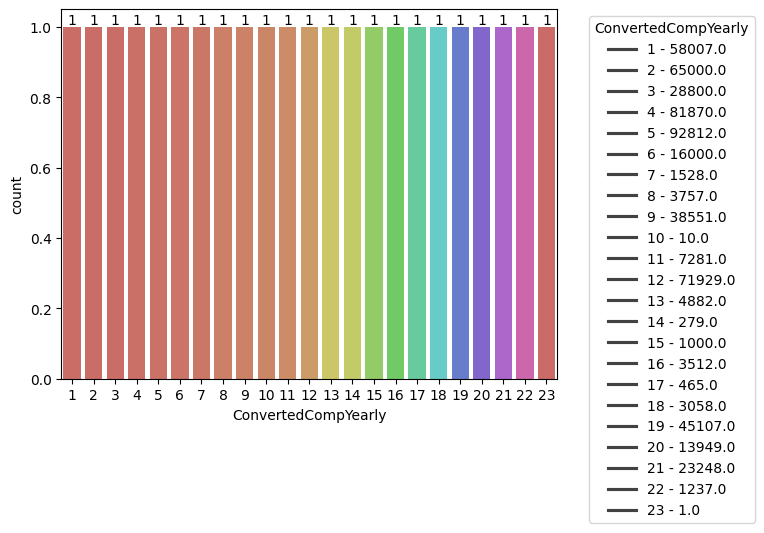

In [92]:
df_temp = df_miss_work_exp.ConvertedCompYearly.value_counts().reset_index()
barplot_column(df_temp, "ConvertedCompYearly")

In [89]:
# Mean income for those with work experience data
df_res_pub_final.loc[~index, 'ConvertedCompYearly'].mean()


np.float64(24447.08695652174)

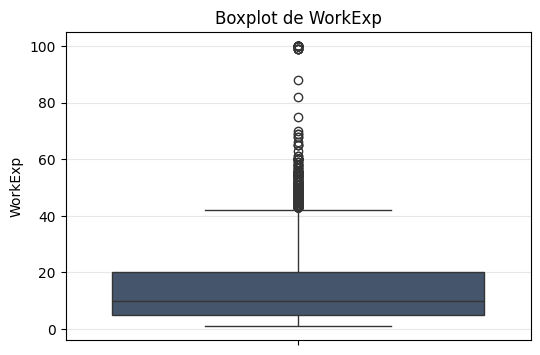

In [36]:
# Boxplot simples e por categoria com seaborn (usa df_res_pub e a variável 'column' já definidas)
# Ajuste 'Employment' para outra coluna categórica se preferir
column = 'WorkExp'
# Boxplot simples (distribuição de JobSat)
plt.figure(figsize=(6, 4))
sns.boxplot(y=df_res_pub[column].dropna(), color=custom_palette(0.6))
plt.title(f'Boxplot de {column}')
plt.ylabel(column)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [ ]:
Consideraremos anos maiores do que 60 como outliers

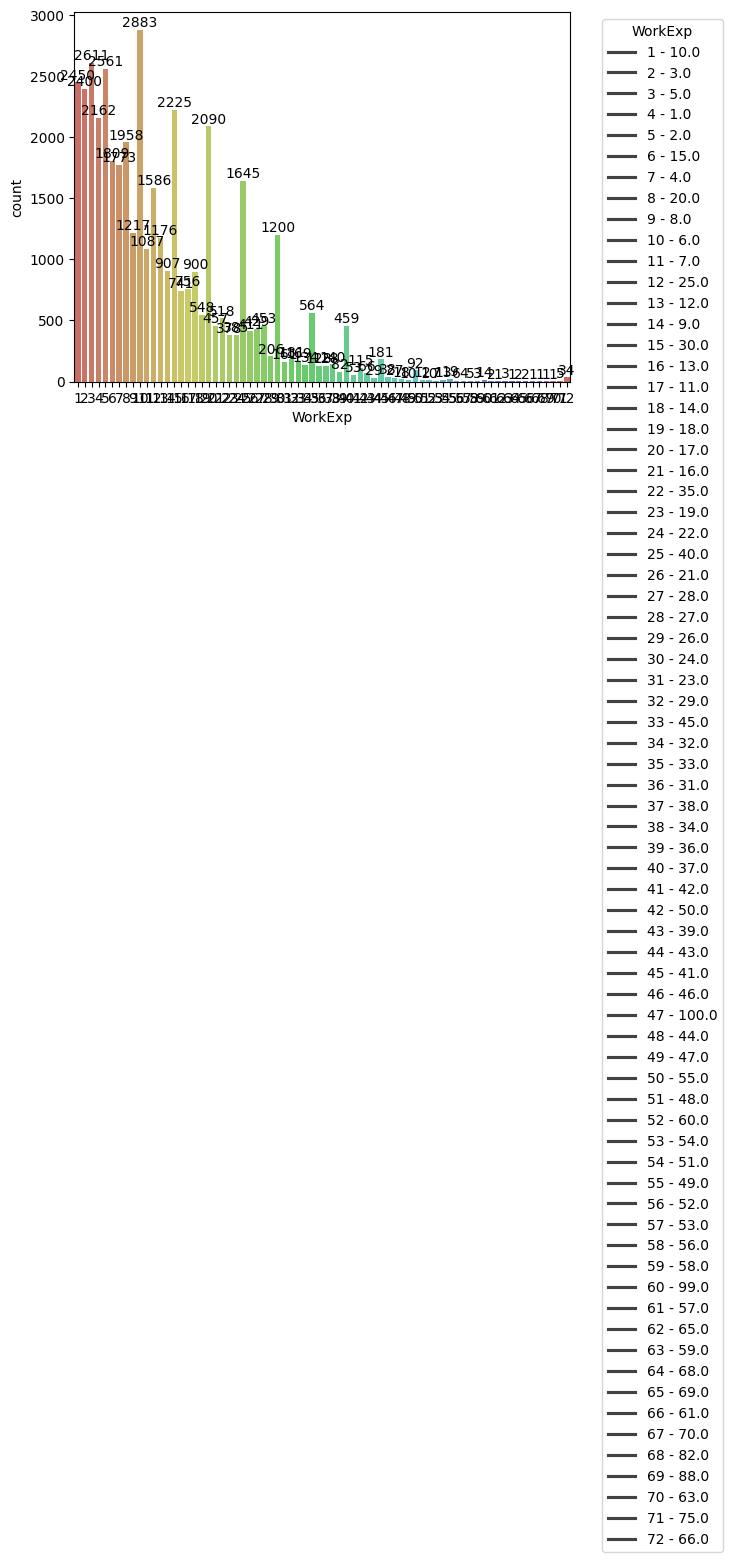

In [34]:
barplot_column(df_work_xp, "WorkExp")

In [54]:
work_experience = df_res_pub_final.WorkExp.value_counts().reset_index()

In [56]:
work_experience

,WorkExp,count
0,10.0,2594
1,5.0,2204
2,3.0,2130
3,15.0,2039
4,4.0,1896
...,...,...
60,65.0,1
61,68.0,1
62,82.0,1
63,59.0,1


In [55]:
df_res_pub_final.WorkExp.value_counts()

WorkExp
10.0    2594
5.0     2204
3.0     2130
15.0    2039
4.0     1896
        ... 
65.0       1
68.0       1
82.0       1
59.0       1
63.0       1
Name: count, Length: 65, dtype: int64

In [40]:
df_res_sch.loc[df_res_sch['qname'] == 'LanguageChoice', 'question'].item()

'Did you work with programming, scripting and markup languages in the last year or do you plan to in the year to come?  Here, we are referring to anything you use that is conventionally referred to as code.'

In [9]:
df_res_sch.head(11)

,qid,qname,question,type,sub,sq_id
0,QID18,TechEndorse_1,What attracts you to a technology or causes yo...,RO,AI integration or AI Agent capabilities,1.0
1,QID18,TechEndorse_2,What attracts you to a technology or causes yo...,RO,Easy-to-use API,2.0
2,QID18,TechEndorse_3,What attracts you to a technology or causes yo...,RO,Robust and complete API,3.0
3,QID18,TechEndorse_4,What attracts you to a technology or causes yo...,RO,Customizable and manageable codebase,4.0
4,QID18,TechEndorse_5,What attracts you to a technology or causes yo...,RO,Reputation for quality,5.0
5,QID18,TechEndorse_6,What attracts you to a technology or causes yo...,RO,Connected to an open-source project,6.0
6,QID18,TechEndorse_7,What attracts you to a technology or causes yo...,RO,Good brand and public image,7.0
7,QID18,TechEndorse_8,What attracts you to a technology or causes yo...,RO,Reliability and low latency,8.0
8,QID18,TechEndorse_9,What attracts you to a technology or causes yo...,RO,Costs are manageable,9.0
9,QID18,TechEndorse_13,What attracts you to a technology or causes yo...,RO,Other (please specify):,10.0


In [14]:
for i in df_res_sch.loc[0:5, 'question']:
    print(i)

What attracts you to a technology or causes you to endorse it (most to least important)?
What attracts you to a technology or causes you to endorse it (most to least important)?
What attracts you to a technology or causes you to endorse it (most to least important)?
What attracts you to a technology or causes you to endorse it (most to least important)?
What attracts you to a technology or causes you to endorse it (most to least important)?
What attracts you to a technology or causes you to endorse it (most to least important)?
